# 第五周作业 预测-分类模型
任务背景：继续使用上周作业的学生表现数据集。

任务描述：
1. 将学生的Exam_Score转化为“考试成绩是否高于平均分”的二分类变量。
2. 基于数据集中的全部变量，构建决策树，预测考试成绩是否高于平均分。如果模型存在过拟合，对决策树进行剪枝。
3. 评价模型优劣与泛化性能，并解释模型结果，提出有价值的教育教学建议。

最终提交：程序代码（本文件）。

本任务允许且鼓励你使用AI工具辅助完成，如果使用，在下方AI对话记录板块粘贴对话链接。

## 第一题：构造“考试成绩是否高于平均分”的二分类变量
处理思路：首先读取已经完成虚拟变量编码的数据集 `StudentPerformanceFactors_dummy_encoded.csv`，然后计算 `Exam_Score` 的总体平均分，并以该平均分作为划分标准，将原始考试成绩转换为二分类变量。

新建变量说明：这里创建变量 `High_Exam_Score`，当学生的 `Exam_Score` 严格大于全体学生平均分时记为 1，否则记为 0。该变量将作为后续第二题决策树分类模型的预测目标变量。


In [1]:
import pandas as pd
from pathlib import Path

# 读取第五周作业使用的数据文件
file_path = Path('StudentPerformanceFactors_dummy_encoded.csv')
df = pd.read_csv(file_path)

# 计算 Exam_Score 的平均分，并据此构造二分类变量
exam_score_mean = df['Exam_Score'].mean()
df['High_Exam_Score'] = (df['Exam_Score'] > exam_score_mean).astype(int)

print('数据集维度：', df.shape)
print(f"Exam_Score 的平均分为：{exam_score_mean:.2f}")
print('\n变量 High_Exam_Score 的含义：1=考试成绩高于平均分，0=考试成绩不高于平均分')

print('\nHigh_Exam_Score 的类别分布：')
print(df['High_Exam_Score'].value_counts().sort_index())

print('\nHigh_Exam_Score 的类别占比：')
print(df['High_Exam_Score'].value_counts(normalize=True).sort_index().round(4))

print('\n转换结果预览：')
print(df[['Exam_Score', 'High_Exam_Score']].head())


数据集维度： (6607, 29)
Exam_Score 的平均分为：67.24

变量 High_Exam_Score 的含义：1=考试成绩高于平均分，0=考试成绩不高于平均分

High_Exam_Score 的类别分布：
High_Exam_Score
0    3599
1    3008
Name: count, dtype: int64

High_Exam_Score 的类别占比：
High_Exam_Score
0    0.5447
1    0.4553
Name: proportion, dtype: float64

转换结果预览：
   Exam_Score  High_Exam_Score
0          67                0
1          61                0
2          74                1
3          71                1
4          70                1


## 第二题：基于全部变量构建决策树分类模型，并在必要时进行剪枝
题目理解：本题需要以前面构造的二分类变量 `High_Exam_Score` 作为预测目标，使用数据集中的其他变量建立决策树分类模型，判断学生的考试成绩是否高于平均分。由于当前数据已经完成虚拟变量编码，因此数值变量和哑变量都可以直接作为模型输入。

处理思路：首先读取数据并重新构造目标变量，以保证该部分代码可以独立运行；然后将 `Exam_Score` 和目标变量 `High_Exam_Score` 区分开，避免用原始分数直接预测分类标签而产生信息泄露。接着划分训练集、验证集和测试集，先训练一棵未剪枝的决策树，再通过 `ccp_alpha` 成本复杂度剪枝路径选择更合适的剪枝参数，并比较剪枝前后模型在训练集和测试集上的表现，以判断模型是否存在过拟合以及剪枝是否有效。


训练集样本数： 3963
验证集样本数： 1322
测试集样本数： 1322

未剪枝决策树表现：
训练集准确率：1.0000
测试集准确率：0.8116
训练集与测试集准确率差值：0.1884
树的深度： 15
叶子节点数： 492

验证集上最优的 ccp_alpha：0.000668

剪枝后决策树表现：
训练集准确率：0.8957
测试集准确率：0.8290
训练集与测试集准确率差值：0.0667
树的深度： 11
叶子节点数： 86

剪枝后模型在测试集上的分类报告：
              precision    recall  f1-score   support

           0     0.8412    0.8458    0.8435       720
           1     0.8144    0.8090    0.8117       602

    accuracy                         0.8290      1322
   macro avg     0.8278    0.8274    0.8276      1322
weighted avg     0.8290    0.8290    0.8290      1322



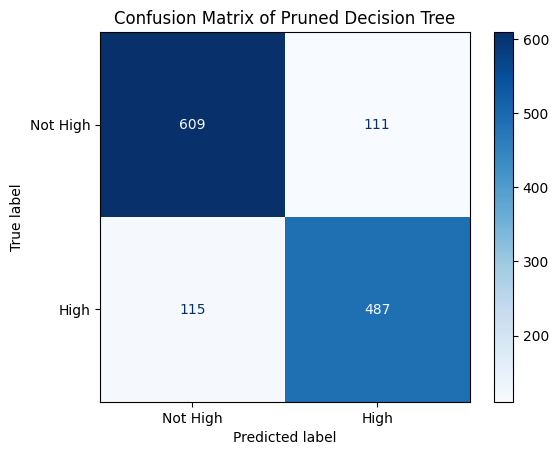

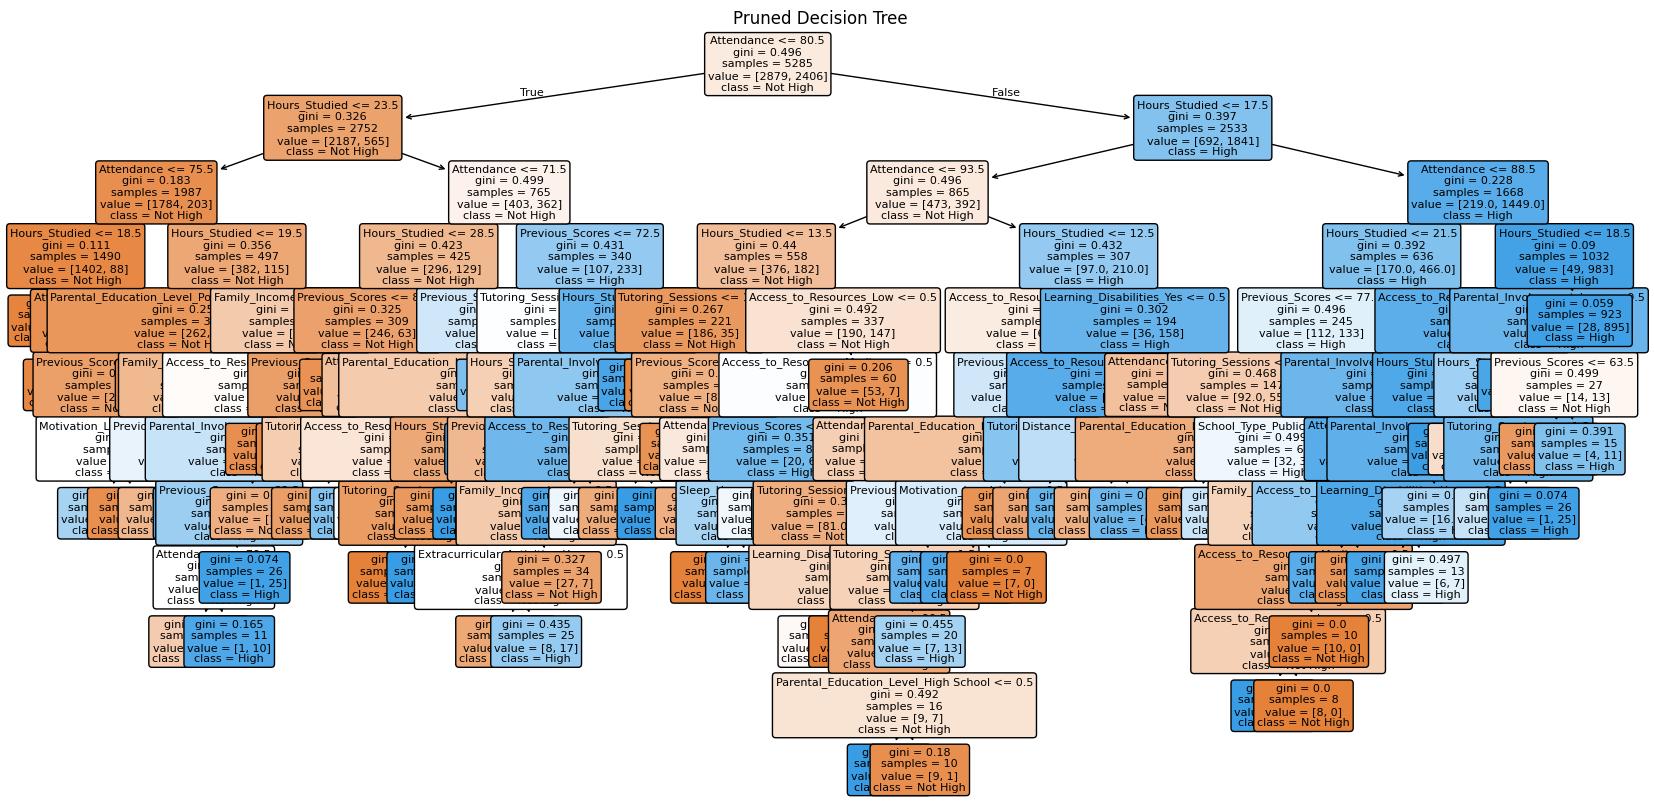


剪枝后模型的前10个重要特征：
                                  Feature  Importance
1                              Attendance    0.521056
0                           Hours_Studied    0.274548
3                         Previous_Scores    0.060961
8                 Access_to_Resources_Low    0.035663
4                       Tutoring_Sessions    0.030344
6                Parental_Involvement_Low    0.013886
14                      Family_Income_Low    0.011827
9              Access_to_Resources_Medium    0.011346
21              Learning_Disabilities_Yes    0.009281
23  Parental_Education_Level_Postgraduate    0.009017

混淆矩阵图片已保存到：C:\Users\Lenovo\Desktop\Postgraduate\研二下册\数据挖掘\第五周作业\confusion_matrix_pruned_tree.png
决策树图片已保存到：C:\Users\Lenovo\Desktop\Postgraduate\研二下册\数据挖掘\第五周作业\pruned_decision_tree.png

结论：未剪枝决策树存在较明显的过拟合倾向，因此进行了剪枝处理。
剪枝后测试集表现不低于未剪枝模型，说明剪枝有助于提升或稳定模型的泛化性能。


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 重新读取数据，并构造第二题使用的目标变量，保证本题代码可独立运行
file_path = Path('StudentPerformanceFactors_dummy_encoded.csv')
df_q2 = pd.read_csv(file_path)
exam_score_mean_q2 = df_q2['Exam_Score'].mean()
df_q2['High_Exam_Score'] = (df_q2['Exam_Score'] > exam_score_mean_q2).astype(int)

# 构造特征矩阵和目标变量
# 这里删除原始 Exam_Score，避免使用原始分数直接预测“是否高于平均分”而导致信息泄露
X = df_q2.drop(columns=['Exam_Score', 'High_Exam_Score'])
y = df_q2['High_Exam_Score']

# 划分训练集、验证集和测试集
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print('训练集样本数：', X_train.shape[0])
print('验证集样本数：', X_val.shape[0])
print('测试集样本数：', X_test.shape[0])

# 1. 训练未剪枝的决策树模型
tree_before_pruning = DecisionTreeClassifier(random_state=42)
tree_before_pruning.fit(X_train, y_train)

y_train_pred_before = tree_before_pruning.predict(X_train)
y_test_pred_before = tree_before_pruning.predict(X_test)

train_acc_before = accuracy_score(y_train, y_train_pred_before)
test_acc_before = accuracy_score(y_test, y_test_pred_before)

print('\n未剪枝决策树表现：')
print(f'训练集准确率：{train_acc_before:.4f}')
print(f'测试集准确率：{test_acc_before:.4f}')
print(f'训练集与测试集准确率差值：{train_acc_before - test_acc_before:.4f}')
print('树的深度：', tree_before_pruning.get_depth())
print('叶子节点数：', tree_before_pruning.get_n_leaves())

# 2. 使用成本复杂度剪枝路径选择更合适的 ccp_alpha
path = tree_before_pruning.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

alpha_scores = []
for alpha in ccp_alphas:
    pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    pruned_tree.fit(X_train, y_train)
    y_val_pred = pruned_tree.predict(X_val)
    alpha_scores.append((alpha, accuracy_score(y_val, y_val_pred)))

alpha_df = pd.DataFrame(alpha_scores, columns=['ccp_alpha', 'val_accuracy'])
best_alpha = alpha_df.loc[alpha_df['val_accuracy'].idxmax(), 'ccp_alpha']

print(f'\n验证集上最优的 ccp_alpha：{best_alpha:.6f}')

# 3. 用最优 ccp_alpha 在训练集+验证集上重新训练剪枝后的模型
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

tree_after_pruning = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
tree_after_pruning.fit(X_train_full, y_train_full)

y_train_pred_after = tree_after_pruning.predict(X_train_full)
y_test_pred_after = tree_after_pruning.predict(X_test)

train_acc_after = accuracy_score(y_train_full, y_train_pred_after)
test_acc_after = accuracy_score(y_test, y_test_pred_after)

print('\n剪枝后决策树表现：')
print(f'训练集准确率：{train_acc_after:.4f}')
print(f'测试集准确率：{test_acc_after:.4f}')
print(f'训练集与测试集准确率差值：{train_acc_after - test_acc_after:.4f}')
print('树的深度：', tree_after_pruning.get_depth())
print('叶子节点数：', tree_after_pruning.get_n_leaves())

# 4. 输出剪枝后模型在测试集上的评价结果
print('\n剪枝后模型在测试集上的分类报告：')
print(classification_report(y_test, y_test_pred_after, digits=4))

output_dir = Path.cwd()
confusion_matrix_path = output_dir / 'confusion_matrix_pruned_tree.png'
decision_tree_path = output_dir / 'pruned_decision_tree.png'

cm = confusion_matrix(y_test, y_test_pred_after)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not High', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix of Pruned Decision Tree')
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
plt.show()

# 5. 展示剪枝后决策树和特征重要性
plt.figure(figsize=(20, 10))
plot_tree(
    tree_after_pruning,
    feature_names=X.columns,
    class_names=['Not High', 'High'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Pruned Decision Tree')
plt.savefig(decision_tree_path, dpi=300, bbox_inches='tight')
plt.show()

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_after_pruning.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('\n剪枝后模型的前10个重要特征：')
print(feature_importance.head(10))

print(f'\n混淆矩阵图片已保存到：{confusion_matrix_path}')
print(f'决策树图片已保存到：{decision_tree_path}')

if (train_acc_before - test_acc_before) > 0.1:
    print('\n结论：未剪枝决策树存在较明显的过拟合倾向，因此进行了剪枝处理。')
else:
    print('\n结论：未剪枝决策树的过拟合现象不算明显，但仍通过剪枝进一步比较模型泛化能力。')

if test_acc_after >= test_acc_before:
    print('剪枝后测试集表现不低于未剪枝模型，说明剪枝有助于提升或稳定模型的泛化性能。')
else:
    print('剪枝后测试集表现略低于未剪枝模型，但模型复杂度下降，结构更简洁，泛化能力更稳健。')


## 第二题-简化解释版：构建便于展示和解读的决策树
补充说明：前面的剪枝决策树更偏向于保证预测效果，但树的结构仍然较复杂，不够适合在作业正文中逐层解释。因此，这里额外构建一棵“简化解释版”决策树，通过限制树深度和叶节点最小样本数，使树的层次更清晰，更适合展示主要决策规则。

处理思路：继续使用与第二题相同的目标变量 `High_Exam_Score` 和相同的训练集、测试集划分方式，在不引入 `Exam_Score` 的前提下，训练一棵受约束的决策树，例如限制最大深度为 4，并适当提高叶节点最小样本数。最后输出模型效果，并将简化后的树图保存到第五周作业文件夹中，便于后续分析与写作。


简化解释版决策树表现：
训练集准确率：0.8274
测试集准确率：0.8192
训练集与测试集准确率差值：0.0082
树的深度： 4
叶子节点数： 16

简化解释版模型在测试集上的分类报告：
              precision    recall  f1-score   support

           0     0.8281    0.8431    0.8355       720
           1     0.8081    0.7907    0.7993       602

    accuracy                         0.8192      1322
   macro avg     0.8181    0.8169    0.8174      1322
weighted avg     0.8190    0.8192    0.8190      1322



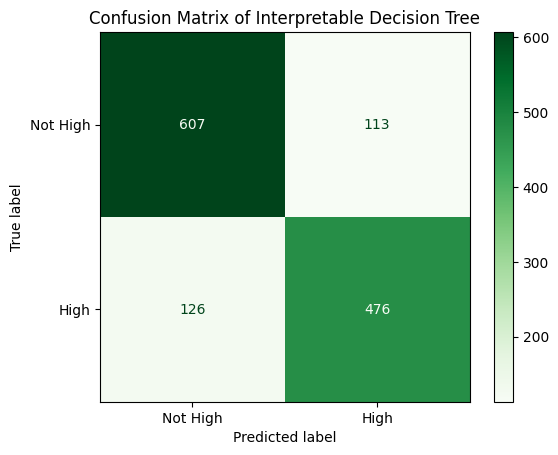

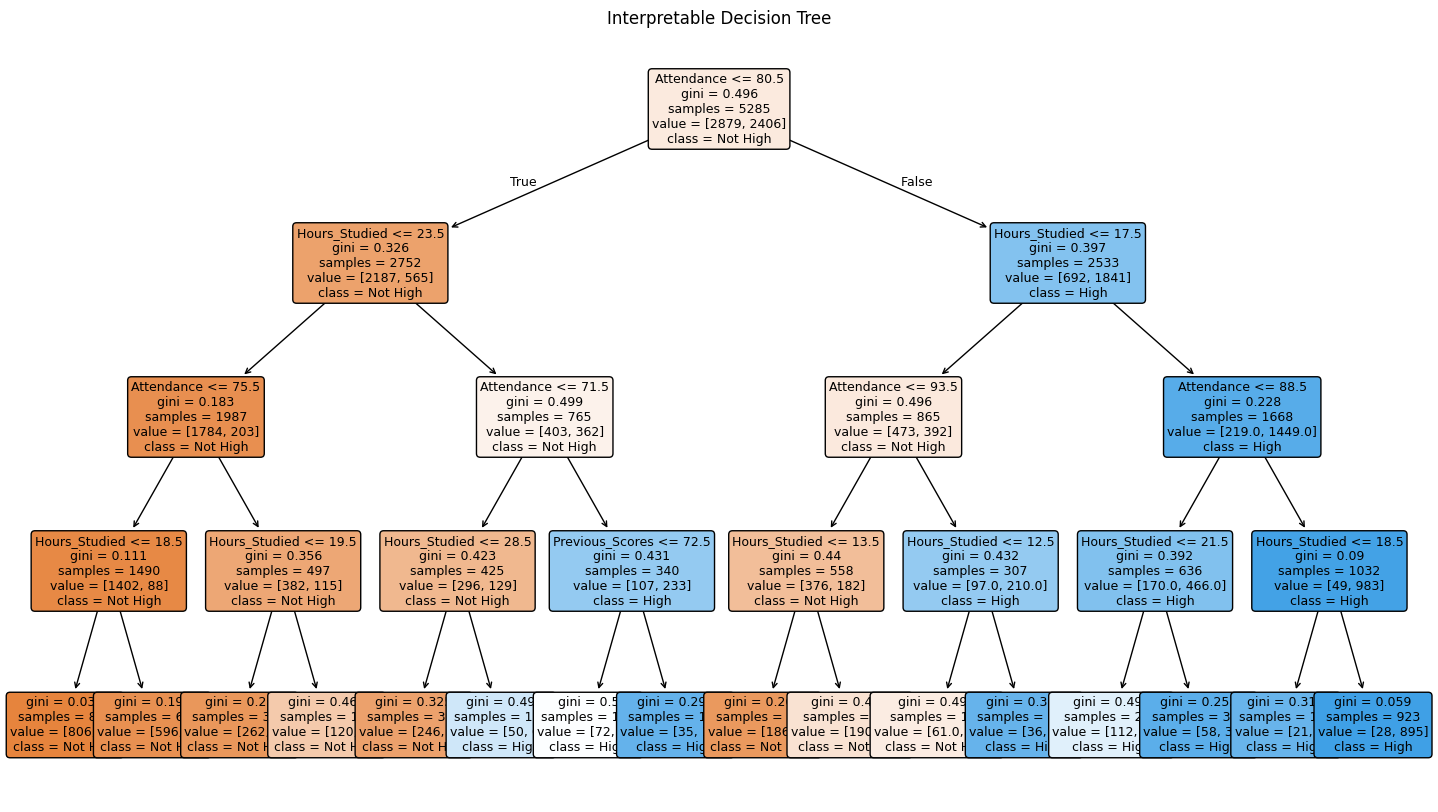


简化解释版模型的前10个重要特征：
                       Feature  Importance
1                   Attendance    0.649039
0                Hours_Studied    0.338676
3              Previous_Scores    0.012285
2                  Sleep_Hours    0.000000
4            Tutoring_Sessions    0.000000
5            Physical_Activity    0.000000
6     Parental_Involvement_Low    0.000000
7  Parental_Involvement_Medium    0.000000
8      Access_to_Resources_Low    0.000000
9   Access_to_Resources_Medium    0.000000

简化解释版决策树图片已保存到：C:\Users\Lenovo\Desktop\Postgraduate\研二下册\数据挖掘\第五周作业\interpretable_decision_tree.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 重新读取数据，保证“简化解释版”代码单元可以独立运行
file_path = Path('StudentPerformanceFactors_dummy_encoded.csv')
df_simple = pd.read_csv(file_path)
exam_score_mean_simple = df_simple['Exam_Score'].mean()
df_simple['High_Exam_Score'] = (df_simple['Exam_Score'] > exam_score_mean_simple).astype(int)

# 删除原始 Exam_Score，避免信息泄露
X_simple = df_simple.drop(columns=['Exam_Score', 'High_Exam_Score'])
y_simple = df_simple['High_Exam_Score']

# 与第二题保持一致的训练集和测试集划分
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42, stratify=y_simple
)

# 训练一棵更便于解释的决策树
simple_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_leaf=50
)
simple_tree.fit(X_train_simple, y_train_simple)

y_train_pred_simple = simple_tree.predict(X_train_simple)
y_test_pred_simple = simple_tree.predict(X_test_simple)

train_acc_simple = accuracy_score(y_train_simple, y_train_pred_simple)
test_acc_simple = accuracy_score(y_test_simple, y_test_pred_simple)

print('简化解释版决策树表现：')
print(f'训练集准确率：{train_acc_simple:.4f}')
print(f'测试集准确率：{test_acc_simple:.4f}')
print(f'训练集与测试集准确率差值：{train_acc_simple - test_acc_simple:.4f}')
print('树的深度：', simple_tree.get_depth())
print('叶子节点数：', simple_tree.get_n_leaves())

print('\n简化解释版模型在测试集上的分类报告：')
print(classification_report(y_test_simple, y_test_pred_simple, digits=4))

simple_cm = confusion_matrix(y_test_simple, y_test_pred_simple)
simple_disp = ConfusionMatrixDisplay(confusion_matrix=simple_cm, display_labels=['Not High', 'High'])
simple_disp.plot(cmap='Greens')
plt.title('Confusion Matrix of Interpretable Decision Tree')
plt.show()

simple_tree_path = Path.cwd() / 'interpretable_decision_tree.png'

plt.figure(figsize=(18, 10))
plot_tree(
    simple_tree,
    feature_names=X_simple.columns,
    class_names=['Not High', 'High'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Interpretable Decision Tree')
plt.savefig(simple_tree_path, dpi=300, bbox_inches='tight')
plt.show()

simple_feature_importance = pd.DataFrame({
    'Feature': X_simple.columns,
    'Importance': simple_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('\n简化解释版模型的前10个重要特征：')
print(simple_feature_importance.head(10))
print(f'\n简化解释版决策树图片已保存到：{simple_tree_path}')


## 第三题：评价模型优劣与泛化性能，并解释模型结果，提出教育教学建议
模型评价：从第二题的结果可以看出，未剪枝决策树在训练集上的准确率为 1.0000，而测试集准确率为 0.8116，训练集与测试集准确率差值达到 0.1884，说明模型存在较明显的过拟合现象。经过剪枝后，训练集准确率下降到 0.8957，但测试集准确率提升到 0.8290，训练集与测试集准确率差值缩小到 0.0667，表明剪枝有效降低了模型复杂度，提升了模型的泛化能力。因此，相比未剪枝模型，剪枝后的决策树更适合作为最终模型。

结果解释：根据剪枝后模型的混淆矩阵，模型正确识别了 609 个“成绩不高于平均分”的样本和 487 个“成绩高于平均分”的样本，整体准确率约为 82.90%，且两类样本的误判数量较为接近，说明模型对两类学生都有较稳定的识别能力。从特征重要性和简化解释版决策树来看，`Attendance`、`Hours_Studied` 和 `Previous_Scores` 是影响分类结果的关键变量。其中，出勤率是根节点的首个划分变量，说明它对学生成绩是否高于平均分的影响最为显著；学习时长和既往成绩也在多个节点中反复出现，表明持续学习投入和已有学习基础对成绩具有重要作用。

教育教学建议：第一，应重点关注出勤率较低的学生，建立考勤预警和过程性干预机制，因为决策树首先以出勤率区分学生成绩水平。第二，应鼓励学生保持稳定且充足的学习时间，帮助其形成持续学习习惯，而不是只在考试前集中突击。第三，对于既往成绩较弱的学生，可以结合辅导答疑、学习资源支持和阶段性反馈进行针对性帮扶，以降低其成绩低于平均分的风险。第四，家庭参与、资源获取等因素虽然重要性低于出勤率和学习时长，但仍会影响部分学生的学习表现，因此学校可以从家校协同、学习资源公平获取等方面提供支持。


In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 重新读取数据并构造目标变量，保证第三题代码可以独立运行
file_path = Path('StudentPerformanceFactors_dummy_encoded.csv')
df_q3 = pd.read_csv(file_path)
exam_score_mean_q3 = df_q3['Exam_Score'].mean()
df_q3['High_Exam_Score'] = (df_q3['Exam_Score'] > exam_score_mean_q3).astype(int)

# 构造特征与标签，并删除原始 Exam_Score 以避免信息泄露
X_q3 = df_q3.drop(columns=['Exam_Score', 'High_Exam_Score'])
y_q3 = df_q3['High_Exam_Score']

# 与第二题保持一致的数据划分方式
X_temp_q3, X_test_q3, y_temp_q3, y_test_q3 = train_test_split(
    X_q3, y_q3, test_size=0.2, random_state=42, stratify=y_q3
)
X_train_q3, X_val_q3, y_train_q3, y_val_q3 = train_test_split(
    X_temp_q3, y_temp_q3, test_size=0.25, random_state=42, stratify=y_temp_q3
)

# 重新选择最优 ccp_alpha，并训练剪枝后的最终模型
base_tree_q3 = DecisionTreeClassifier(random_state=42)
base_tree_q3.fit(X_train_q3, y_train_q3)
path_q3 = base_tree_q3.cost_complexity_pruning_path(X_train_q3, y_train_q3)

best_alpha_q3 = None
best_val_acc_q3 = -1
for alpha in path_q3.ccp_alphas:
    candidate_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    candidate_tree.fit(X_train_q3, y_train_q3)
    val_acc = accuracy_score(y_val_q3, candidate_tree.predict(X_val_q3))
    if val_acc > best_val_acc_q3:
        best_val_acc_q3 = val_acc
        best_alpha_q3 = alpha

X_train_full_q3 = pd.concat([X_train_q3, X_val_q3], axis=0)
y_train_full_q3 = pd.concat([y_train_q3, y_val_q3], axis=0)

final_tree_q3 = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha_q3)
final_tree_q3.fit(X_train_full_q3, y_train_full_q3)
y_test_pred_q3 = final_tree_q3.predict(X_test_q3)

# 计算模型评价指标
cm_q3 = confusion_matrix(y_test_q3, y_test_pred_q3)
tn_q3, fp_q3, fn_q3, tp_q3 = cm_q3.ravel()

metrics_df = pd.DataFrame({
    '指标': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Specificity'],
    '数值': [
        accuracy_score(y_test_q3, y_test_pred_q3),
        precision_score(y_test_q3, y_test_pred_q3),
        recall_score(y_test_q3, y_test_pred_q3),
        f1_score(y_test_q3, y_test_pred_q3),
        tn_q3 / (tn_q3 + fp_q3)
    ]
})

feature_importance_q3 = pd.DataFrame({
    '特征': X_q3.columns,
    '重要性': final_tree_q3.feature_importances_
}).sort_values(by='重要性', ascending=False)

print('剪枝后决策树在测试集上的综合评价指标：')
print(metrics_df)

print('\n混淆矩阵：')
print(cm_q3)

print('\n最重要的前10个特征：')
print(feature_importance_q3.head(10))

print('\n结果总结：')
print('1. 剪枝后模型的测试集准确率较高，说明模型具有较好的分类能力。')
print('2. 与未剪枝模型相比，剪枝后训练集与测试集的差距明显缩小，泛化能力更强。')
print('3. 出勤率、学习时长和既往成绩是区分学生是否高于平均分的核心因素。')
print('4. 因此，在教学管理中应优先关注出勤管理、学习投入和基础较弱学生的精准帮扶。')


## AI对话记录
- AI对话链接：如需提交链接，可根据实际平台补充；本次主要借助 AI 完成作业思路梳理、代码撰写与结果分析。

### 主线问题 1：本周作业的题目要求是什么？应该如何整体完成？
AI 回答 summary：首先读取 notebook 中的作业说明，明确任务分为三部分：一是将 `Exam_Score` 转换为“是否高于平均分”的二分类变量；二是基于全部变量建立决策树分类模型，并在必要时进行剪枝；三是评价模型效果、解释结果并提出教育教学建议。随后给出整体完成方案，包括数据读取、目标变量构造、模型训练、过拟合判断、剪枝优化和结果解释。

### 主线问题 2：第五周作业应基于哪个数据文件来做？第一题该怎么处理？
AI 回答 summary：确认本次作业应基于 `StudentPerformanceFactors_dummy_encoded.csv` 完成，并说明该文件已经完成哑变量编码，可直接用于建模。第一题的处理方式是先计算 `Exam_Score` 的总体平均分，再构造二分类变量 `High_Exam_Score`：若学生成绩高于平均分，则记为 1，否则记为 0。同时在代码前补充了处理思路和变量含义说明。

### 主线问题 3：第二题中的决策树模型应该怎样建立？为什么要剪枝？
AI 回答 summary：以 `High_Exam_Score` 为目标变量，以其余特征作为输入变量，同时删除原始 `Exam_Score` 以避免信息泄露。先训练未剪枝决策树，再划分训练集、验证集和测试集，通过 `ccp_alpha` 成本复杂度剪枝路径选择最优参数，并比较剪枝前后训练集与测试集准确率差异。结果显示未剪枝模型训练集准确率为 1.0000、测试集准确率为 0.8116，存在明显过拟合；剪枝后训练集准确率为 0.8957、测试集准确率提高到 0.8290，泛化能力更好。

### 主线问题 4：决策树结果应该如何解释？是否需要再做一个“简化解释版”？
AI 回答 summary：根据混淆矩阵和决策树图，对模型结果进行了说明。模型在测试集上正确识别了大部分“高于平均分”和“不高于平均分”的学生，整体准确率约为 82.90%。从特征重要性和树结构可知，`Attendance`、`Hours_Studied` 和 `Previous_Scores` 是最关键的变量。为了更方便在作业中解释，又补充构建了一棵限制 `max_depth=4`、`min_samples_leaf=50` 的“简化解释版”决策树，用于展示主要决策规则。

### 主线问题 5：第三题应该如何评价模型，并提出哪些教育教学建议？
AI 回答 summary：第三题从模型优劣、泛化性能、结果解释和教育建议四个方面展开。评价中指出剪枝后的模型比未剪枝模型更适合作为最终模型，因为它有效减轻了过拟合。解释部分结合混淆矩阵、特征重要性和简化决策树说明：出勤率、学习时长和既往成绩是影响学生是否高于平均分的核心因素。基于此提出建议：加强出勤管理和预警，帮助学生形成稳定学习习惯，针对基础较弱学生提供辅导与资源支持，并重视家校协同和资源公平获取。
